In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

#### Downloading and Preprocessing the data

In [2]:
BUFFER_SIZE = 70000
BATCH_SIZE = 128
NUM_EPOCHS = 20

In [3]:
mnist_dataset, mnist_info = tfds.load(name = 'mnist', with_info = True, as_supervised=True)

In [4]:
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

In [5]:
def scale(image,label):
    image = tf.cast(image,tf.float32)
    image /= 255.
    return image,label


In [6]:
train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [7]:
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples,tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples,tf.int64)

In [8]:
train_and_validation_data = train_and_validation_data.shuffle(BUFFER_SIZE)
train_data = train_and_validation_data.skip(num_validation_samples)
validation_data = train_and_validation_data.take(num_validation_samples)

In [9]:
train_data = train_data.batch(BATCH_SIZE)

In [10]:
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

#### Create the model and train it

In [11]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(50,5,activation='relu',input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(50,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10)
])

/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/53-Convolutional-Neural-Networks-with-TensorFlow-in-Python/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary(line_length=75)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape            ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                │ (None, 24, 24, 50)      │        1,300 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ max_pooling2d (MaxPooling2D)   │ (None, 12, 12, 50)      │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ conv2d_1 (Conv2D)              │ (None, 10, 10, 50)      │       22,550 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ max_pooling2d_1 (MaxPooling2D) │ (None, 5, 5, 50)        │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ flatten (Flatten)              │ (None, 1250)            │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ dense (Dense)                  │ (None, 10)              │       12,510 │
└────────────────────────────────┴─────────────────────────┴──────────────┘

 Total params: 36,360 (142.03 KB)

 Trainable params: 36,360 (142.03 KB)

 Non-trainable params: 0 (0.00 B)

First dimension in all the layers is None because all data is batched. Thus we don't pass a single image of size 28*28*1 but actually passes a batch of thousand images all at once. That's supposed to be the first dimension, however model does not know our batch size just yet as we have not trained it. So, it leaves this dimension as None.    
      
Trainable parameters are just weights of our network. The parameters that the model is trying to learn. Sometimes, however, you may need to multiply your input by a constant number, say 2.6 and you would want that to happen everytime. In other words, this parameter should not be changed during the learning process. These kinds of parameters are non-trainable.   

In [13]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer='adam',loss=loss_fn,metrics=['accuracy'])

In [14]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='auto',
    min_delta=0,
    patience=2,
    verbose=0,
    restore_best_weights=True
)
# Here these parameters define that program should stop the training process when the validation loss starts to increase for two subsequent 
# epochs because patience=2.

In [15]:
model.fit(
    train_data,
    epochs = NUM_EPOCHS,
    callbacks = [early_stopping],
    validation_data=validation_data,
    verbose =2 #this specifies what to print out during the training process. verbose = 2 means it will print info only at the end 
    # of each epoch while verbose = 1 displays progress bar for every batch
)

Epoch 1/20


/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/53-Convolutional-Neural-Networks-with-TensorFlow-in-Python/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786942201.773375  167836 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


422/422 - 8s - 18ms/step - accuracy: 0.9201 - loss: 0.2728 - val_accuracy: 0.9743 - val_loss: 0.0891
Epoch 2/20
422/422 - 8s - 18ms/step - accuracy: 0.9788 - loss: 0.0713 - val_accuracy: 0.9847 - val_loss: 0.0524
Epoch 3/20
422/422 - 7s - 17ms/step - accuracy: 0.9836 - loss: 0.0524 - val_accuracy: 0.9893 - val_loss: 0.0373
Epoch 4/20
422/422 - 7s - 17ms/step - accuracy: 0.9870 - loss: 0.0425 - val_accuracy: 0.9892 - val_loss: 0.0336
Epoch 5/20
422/422 - 8s - 19ms/step - accuracy: 0.9888 - loss: 0.0350 - val_accuracy: 0.9922 - val_loss: 0.0265
Epoch 6/20
422/422 - 8s - 18ms/step - accuracy: 0.9910 - loss: 0.0304 - val_accuracy: 0.9933 - val_loss: 0.0232
Epoch 7/20
422/422 - 8s - 18ms/step - accuracy: 0.9915 - loss: 0.0267 - val_accuracy: 0.9930 - val_loss: 0.0211
Epoch 8/20
422/422 - 8s - 19ms/step - accuracy: 0.9929 - loss: 0.0227 - val_accuracy: 0.9945 - val_loss: 0.0186
Epoch 9/20
422/422 - 8s - 18ms/step - accuracy: 0.9936 - loss: 0.0212 - val_accuracy: 0.9948 - val_loss: 0.0174
Epo

### Testing our model 

In [16]:
# testing our model
test_loss, test_accuracy = model.evaluate(test_data)
# printing the test results
print('Test loss: {0:.4f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step - accuracy: 0.9908 - loss: 0.0283
Test loss: 0.0283. Test accuracy: 99.08%


### Plotting images and the results

In [18]:
import matplotlib.pyplot as plt
import numpy as np

In [19]:
# split the test_data into 2 arrays, containing the images and the corresponding labels
for images,labels in test_data.take(1):
    images_test = images.numpy()
    labels_test = labels.numpy()

# Reshape the images into 28*28 form, suitable for matplotlib (original dimension: 28*28*1)
images_plot = np.reshape(images_test,(10000,28,28))

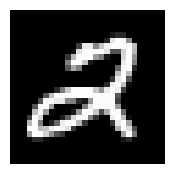

Label: 2


In [ ]:
# The image to be displayed and tested

i = 1 # check with other numbers also for multiple images

# Plot the image
plt.figure(figsize=(2,2))
plt.axis('off')
plt.imshow(images_plot[i-1], cmap = 'gray', aspect='auto')
plt.show()

# Print the correct label for the image
print("Label: {}".format(labels_test[i-1]))

Now, we see the model's output for this image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


<BarContainer object of 10 artists>

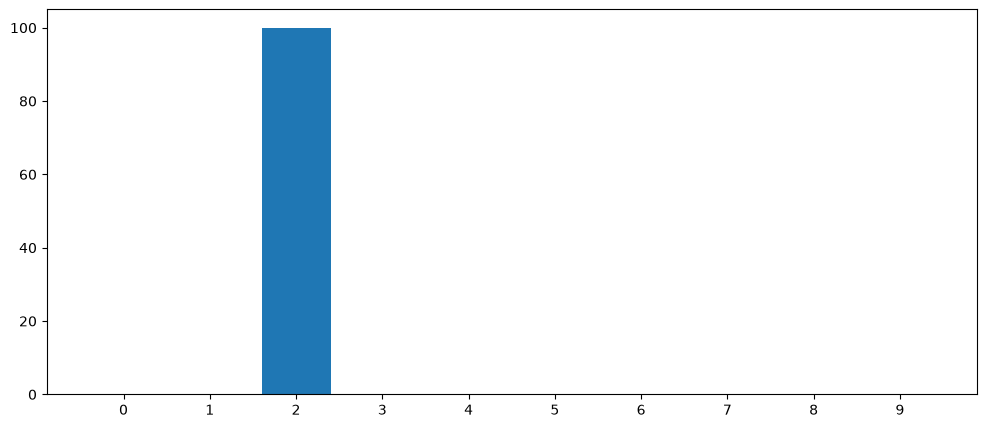

In [21]:
# Obtain the model's predictions (logits)
predictions = model.predict(images_test[i-1:i])

# convert those predictions into probabilities
probabilities = tf.nn.softmax(predictions).numpy()
# convert the probabilities into percentages
probabilities = probabilities*100

# create a bar chart to plot the probabilities for each class
plt.figure(figsize=(12,5))
plt.bar(x=[1,2,3,4,5,6,7,8,9,10],height=probabilities[0], tick_label = ["0","1","2","3","4","5","6","7","8","9"])